In [ ]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("="*50)
print("TensorFlow :", tf.__version__)
print("="*50)

TensorFlow : 2.20.0


In [ ]:
from google.colab import files

files.upload()

In [ ]:
!unzip -q datasetCV.zip

In [ ]:
# ==========================================
# LOKASI DATASET
# ==========================================

dataset_path = "/content/kaggle-genki4k"

print(dataset_path)

/content/kaggle-genki4k


In [ ]:
# ==========================================
# CEK DATASET
# ==========================================

smile_path = os.path.join(dataset_path, "smile")
non_smile_path = os.path.join(dataset_path, "non_smile")

print("Smile :", len(os.listdir(smile_path)))
print("Non Smile :", len(os.listdir(non_smile_path)))

Smile : 2162
Non Smile : 1838


In [ ]:
# ==========================================
# DATA AUGMENTATION
# ==========================================

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,

    horizontal_flip=True,

    fill_mode="nearest"

)

test_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input

)

In [ ]:
# ==========================================
# TRAIN GENERATOR
# ==========================================

train_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="binary",

    subset="training",

    shuffle=True

)

Found 3201 images belonging to 2 classes.


In [ ]:
# ==========================================
# VALIDATION GENERATOR
# ==========================================

validation_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="binary",

    subset="validation",

    shuffle=False

)

Found 799 images belonging to 2 classes.


In [ ]:
print(train_generator.class_indices)

{'non_smile': 0, 'smile': 1}


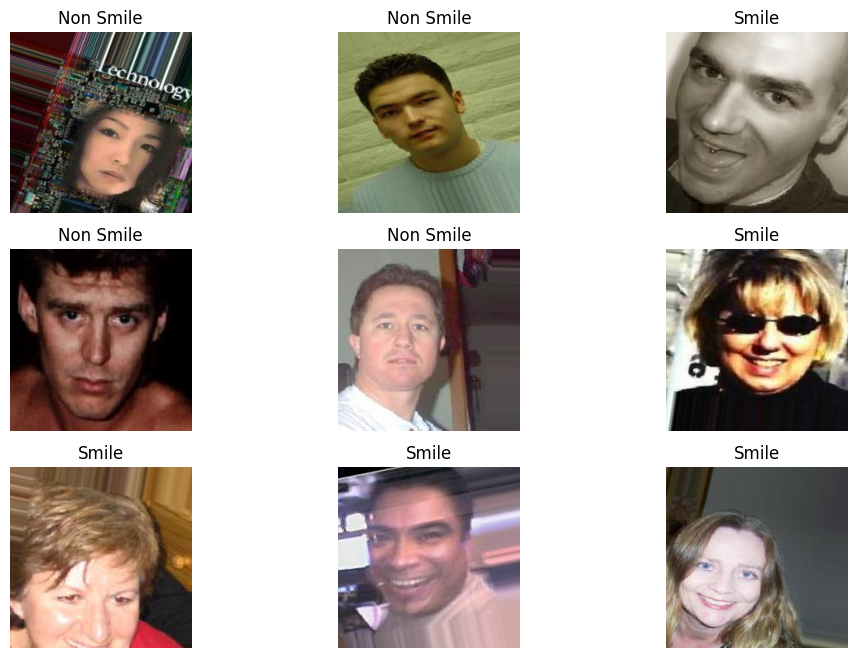

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow((images[i]+1)/2)

    plt.title("Smile" if labels[i]==1 else "Non Smile")

    plt.axis("off")

plt.show()

In [ ]:
# ==========================================
# LOAD MOBILENETV2
# ==========================================

base_model = MobileNetV2(

    input_shape=(224,224,3),

    include_top=False,

    weights="imagenet"

)

base_model.trainable = False

print("Jumlah Layer :", len(base_model.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Jumlah Layer : 154


In [ ]:
# ==========================================
# MEMBANGUN MODEL
# ==========================================

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ==========================================
# COMPILE MODEL
# ==========================================

model.compile(

    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

print("Model berhasil di-compile")

Model berhasil di-compile


In [ ]:
# ==========================================
# EARLY STOPPING
# ==========================================

early_stop = EarlyStopping(

    monitor="val_accuracy",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

In [ ]:
# ==========================================
# MODEL CHECKPOINT
# ==========================================

checkpoint = ModelCheckpoint(

    "best_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

In [ ]:
# ==========================================
# REDUCE LR
# ==========================================

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    min_lr=1e-6,

    verbose=1

)

In [ ]:
print(model.input_shape)
print(model.output_shape)

(None, 224, 224, 3)
(None, 1)


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ==========================================
# TRAINING TAHAP 1
# ==========================================

history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=20,

    callbacks=[

        early_stop,

        checkpoint,

        reduce_lr

    ]

)

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.5339 - loss: 0.7826
Epoch 1: val_accuracy improved from None to 0.65707, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 94s 747ms/step - accuracy: 0.5598 - loss: 0.7442 - val_accuracy: 0.6571 - val_loss: 0.6254 - learning_rate: 1.0000e-04
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.5977 - loss: 0.6843
Epoch 2: val_accuracy improved from 0.65707 to 0.70338, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 47s 463ms/step - accuracy: 0.6036 - loss: 0.6781 - val_accuracy: 0.7034 - val_loss: 0.6039 - learning_rate: 1.0000e-04
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.6356 - loss: 0.6561
Epoch 3: val_accuracy did not improve from 0.70338
101/101 ━━━━━━━━━━━━━━━━━━━━ 46s 460ms/step - accuracy: 0.6357 - loss: 0.6513 - val_accuracy: 0.6921 - val_los

In [ ]:
# ==========================================
# FINE TUNING
# ==========================================

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Layer yang dilatih:")

for layer in base_model.layers[-10:]:
    print(layer.name, layer.trainable)

Layer yang dilatih:
block_16_expand_BN True
block_16_expand_relu True
block_16_depthwise True
block_16_depthwise_BN True
block_16_depthwise_relu True
block_16_project True
block_16_project_BN True
Conv_1 True
Conv_1_bn True
out_relu True


In [ ]:
# ==========================================
# COMPILE ULANG
# ==========================================

model.compile(

    optimizer=Adam(

        learning_rate=1e-5

    ),

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [ ]:
# ==========================================
# TRAINING TAHAP 2
# ==========================================

history_fine = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=10,

    callbacks=[

        early_stop,

        checkpoint,

        reduce_lr

    ]

)

Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.6721 - loss: 0.5987
Epoch 1: val_accuracy did not improve from 0.73592
101/101 ━━━━━━━━━━━━━━━━━━━━ 80s 621ms/step - accuracy: 0.6773 - loss: 0.5944 - val_accuracy: 0.7359 - val_loss: 0.5471 - learning_rate: 1.0000e-05
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.7231 - loss: 0.5490
Epoch 2: val_accuracy did not improve from 0.73592
101/101 ━━━━━━━━━━━━━━━━━━━━ 47s 471ms/step - accuracy: 0.7170 - loss: 0.5562 - val_accuracy: 0.7334 - val_loss: 0.5308 - learning_rate: 1.0000e-05
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.7234 - loss: 0.5522
Epoch 3: val_accuracy improved from 0.73592 to 0.76095, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 478ms/step - accuracy: 0.7413 - loss: 0.5321 - val_accuracy: 0.7610 - val_loss: 0.5221 - learning_rate: 1.0000e-05
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/

In [ ]:
# ==========================================
# GABUNG HISTORY
# ==========================================

acc = history.history["accuracy"] + history_fine.history["accuracy"]

val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

loss = history.history["loss"] + history_fine.history["loss"]

val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

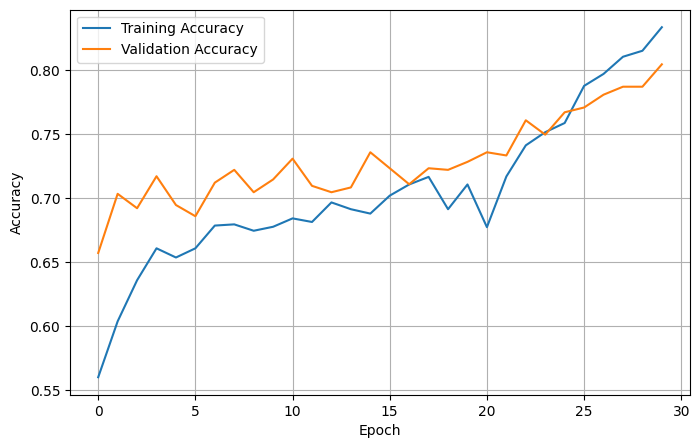

In [ ]:
# ==========================================
# GRAFIK ACCURACY
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(acc,label="Training Accuracy")

plt.plot(val_acc,label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

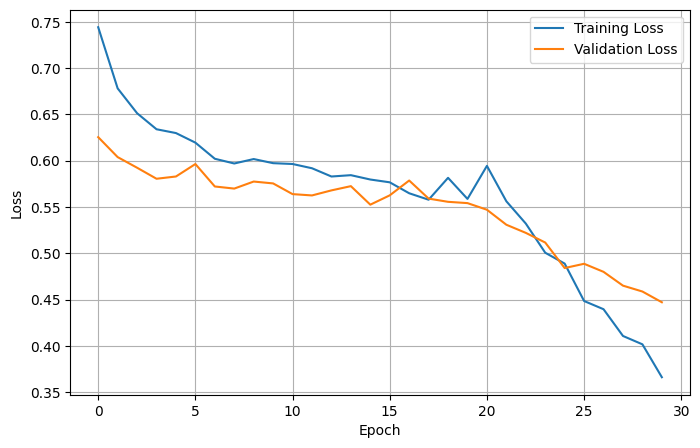

In [ ]:
# ==========================================
# GRAFIK LOSS
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(loss,label="Training Loss")

plt.plot(val_loss,label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# LOAD MODEL TERBAIK
# ==========================================

from tensorflow.keras.models import load_model

model = load_model("best_model.keras")

print("Best model berhasil dimuat")

Best model berhasil dimuat


In [ ]:
# ==========================================
# EVALUASI MODEL
# ==========================================

loss, accuracy = model.evaluate(
    validation_generator,
    verbose=1
)

print("="*50)
print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy*100:.2f}%")
print("="*50)

25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 533ms/step - accuracy: 0.8085 - loss: 0.4205
Validation Loss     : 0.4205
Validation Accuracy : 80.85%


In [ ]:
# ==========================================
# PREDIKSI VALIDATION
# ==========================================

validation_generator.reset()

predictions = model.predict(
    validation_generator,
    verbose=1
)

y_pred = (predictions > 0.5).astype(int).flatten()

y_true = validation_generator.classes

print("Jumlah Data :", len(y_true))

25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 920ms/step
Jumlah Data : 799


<Figure size 600x600 with 0 Axes>

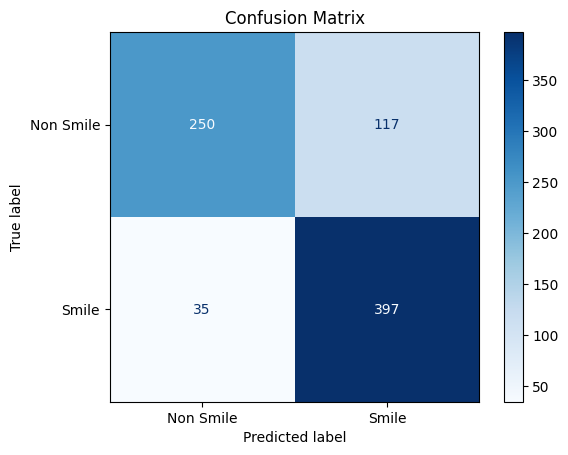

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non Smile","Smile"]
)

plt.figure(figsize=(6,6))

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Non Smile",
            "Smile"
        ]
    )
)

              precision    recall  f1-score   support

   Non Smile       0.88      0.68      0.77       367
       Smile       0.77      0.92      0.84       432

    accuracy                           0.81       799
   macro avg       0.82      0.80      0.80       799
weighted avg       0.82      0.81      0.81       799



In [ ]:
# ==========================================
# SIMPAN MODEL FINAL
# ==========================================

model.save("smile_model.keras")

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [ ]:
from google.colab import files

files.download("smile_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>